# MNE-PythonによるMEG/EEG解析の概要

## pythonモジュールのインポート

In [1]:
import numpy as np

import mne

In [15]:
import lzma

## データの読み込み

In [ ]:
# プログラム1
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
)
raw = mne.io.read_raw_fif(sample_data_raw_file)

Using default location ~/mne_data for sample...
Fetching 1 file for the sample dataset ...


100%|██████████████████████████████████████| 1.65G/1.65G [00:00<00:00, 971GB/s]
Untarring contents of '/Users/r.shimbo/mne_data/MNE-sample-data-processed.tar.gz' to '/Users/r.shimbo/mne_data'


Attempting to create new mne-python configuration file:
/Users/r.shimbo/.mne/mne-python.json
Could not read the /Users/r.shimbo/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 03m20s (1576.2 MB)
Opening raw data file /Users/r.shimbo/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.


In [ ]:
# プログラム2
print(raw)
print(raw.info)

<Raw | sample_audvis_filt-0-40_raw.fif, 376 x 41700 (277.7 s), ~3.2 MiB, data not loaded>
<Info | 15 non-empty values
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 40.0 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off, Average EEG reference: off
 sfreq: 150.2 Hz
>


Effective window size : 13.639 (s)
Plotting power spectral density (dB=True).
Using matplotlib as 2D backend.


/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: divide by zero encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: overflow encountered in matmul
  data = self.mne.projector @ data
/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/mne/viz/_figure.py:385: RuntimeWarning: invalid value encountered in matmul
  data = self.mne.projector @ data


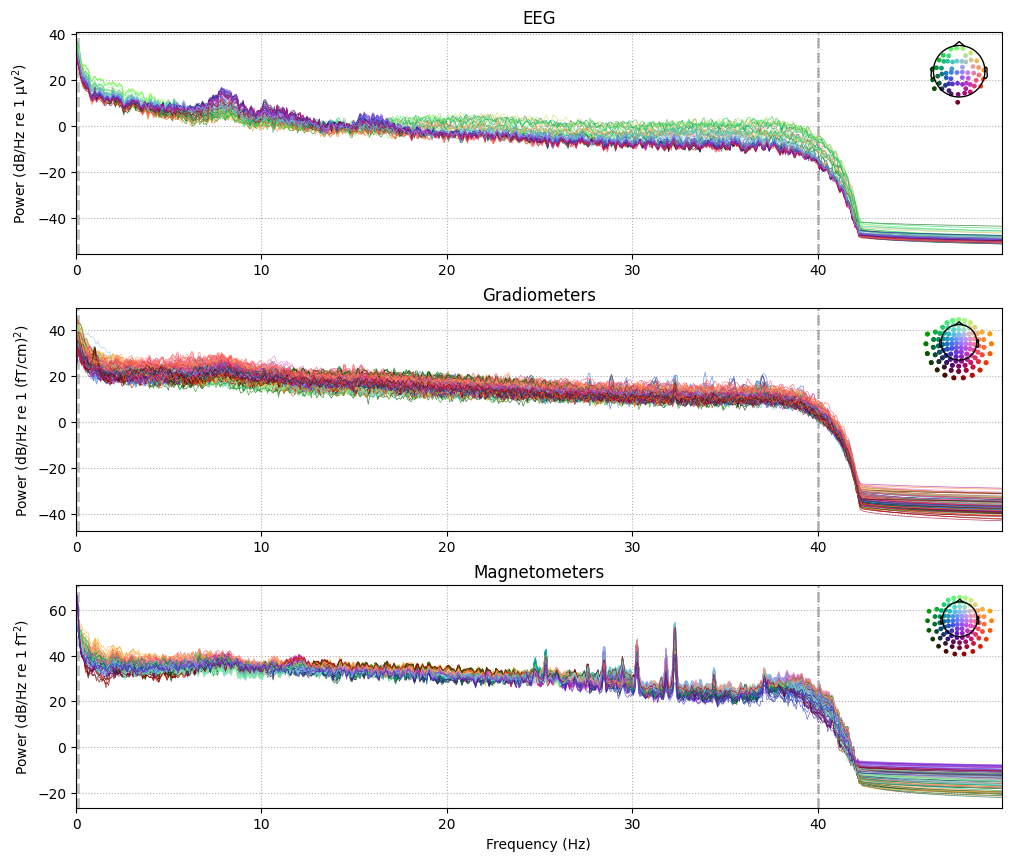

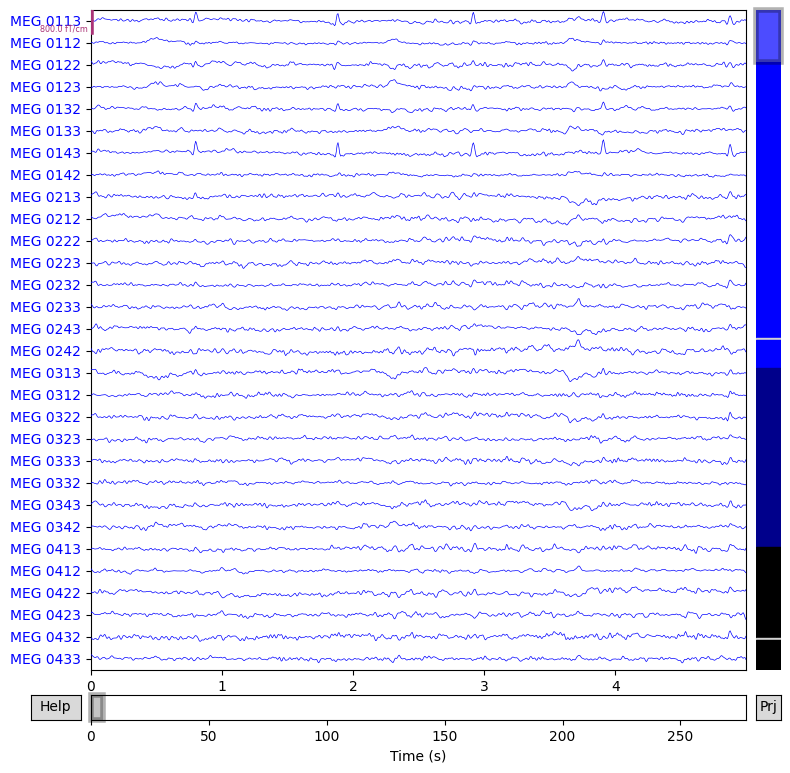

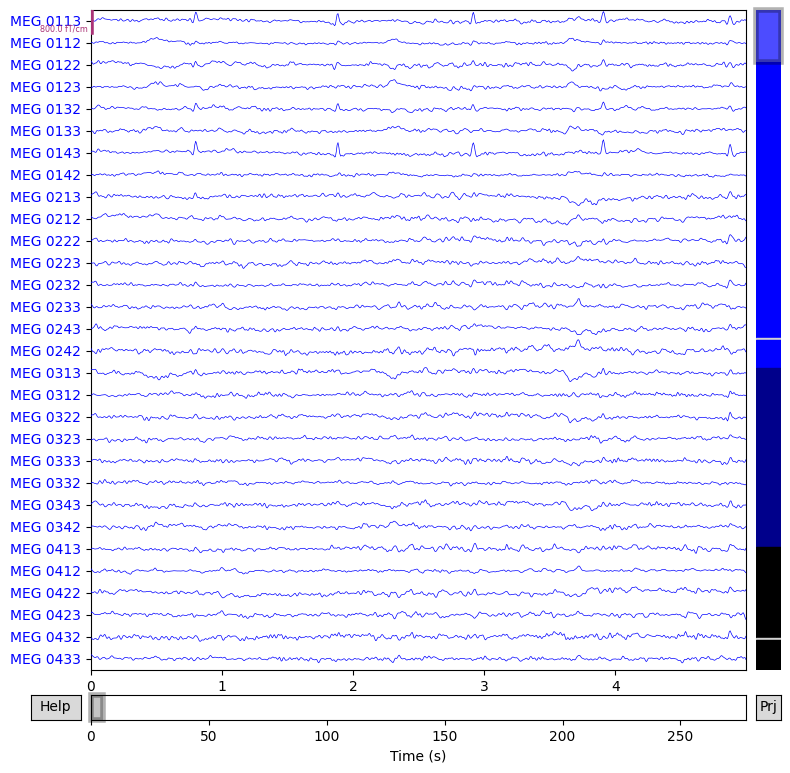

In [ ]:
# プログラム3
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=5, n_channels=30)

## 前処理